In [9]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../data/processed/telco_clean.csv")

In [11]:
X = df.drop(columns=["Churn Label"])

y = df["Churn Label"].map({
    "No":0,
    "Yes":1
})

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

In [14]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [15]:
model = joblib.load(
    "../models/final_xgboost_model.pkl"
)

In [16]:
explainer = shap.TreeExplainer(model)

In [17]:
shap_values = explainer.shap_values(X_test_processed)

In [18]:
feature_names = preprocessor.get_feature_names_out()

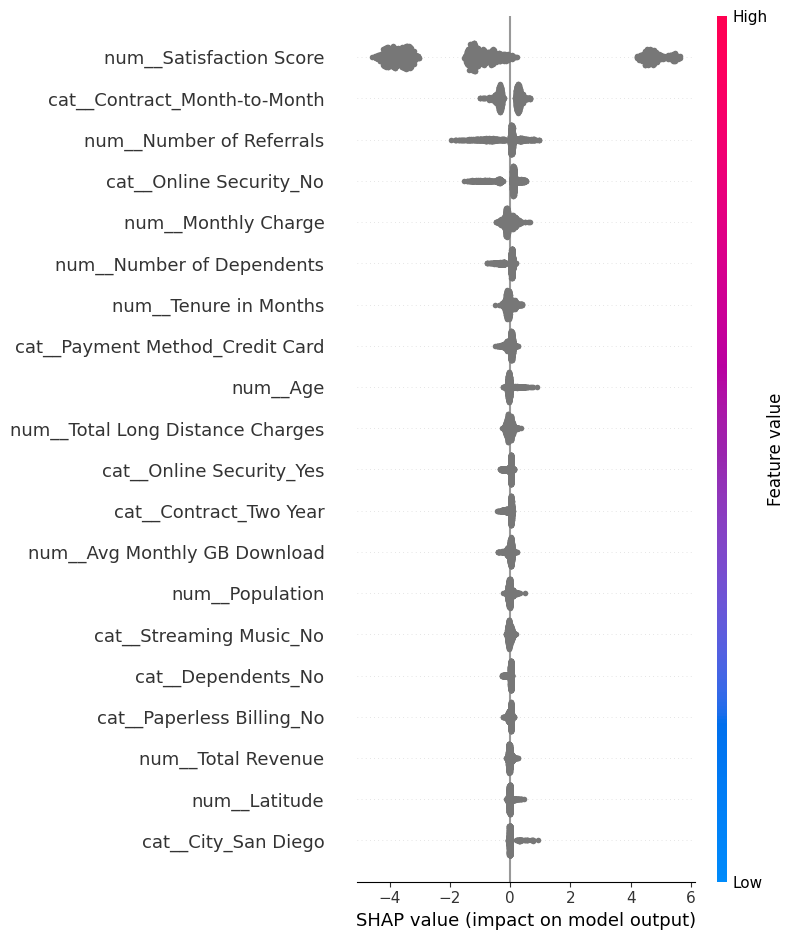

In [19]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

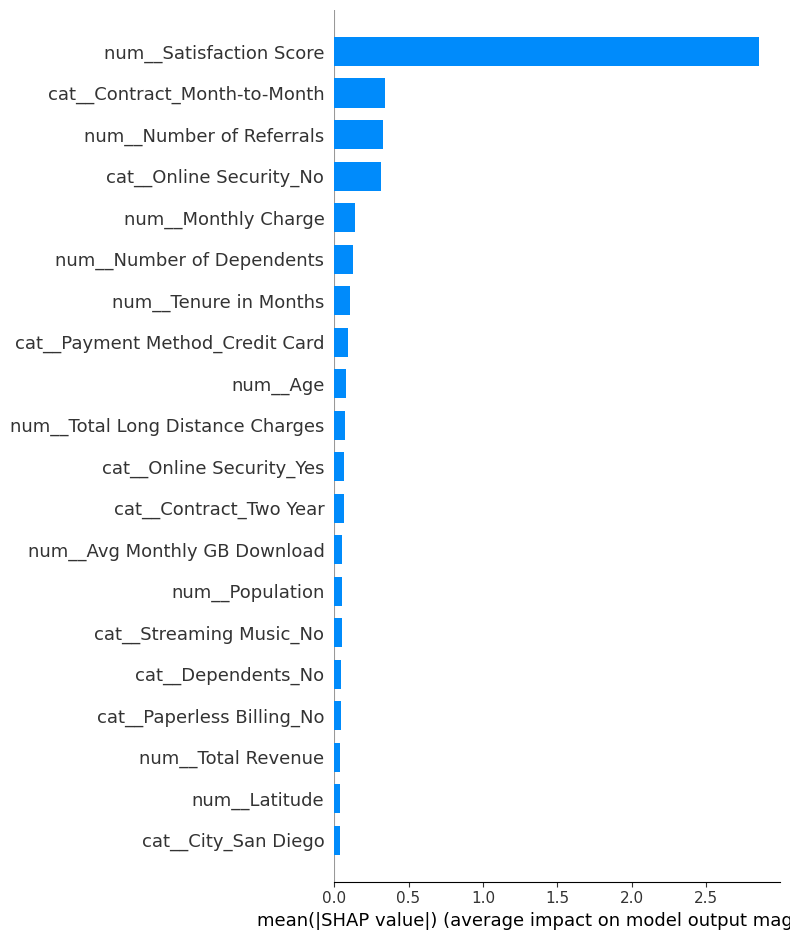

In [20]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

In [21]:
customer = 10

In [ ]:
prob = model.predict_proba(
    X_test_processed[customer].reshape(1,-1)

)
print(prob)

[[0.43667614 0.56332386]]


# Summary

In this notebook we:

- Loaded the optimized XGBoost model
- Used SHAP to explain predictions
- Identified the most important features
- Explained an individual customer's prediction
- Improved the interpretability of the machine learning model

# SHAP Interpretation

The SHAP analysis explains how individual features influence the model's predictions.

Key observations:

- Satisfaction Score is the most influential feature in predicting customer churn.
- Customers with Month-to-Month contracts have a higher likelihood of churning.
- Online Security significantly impacts customer retention.
- Monthly Charges, Number of Referrals, and Tenure also contribute to the prediction.

The SHAP summary and bar plots improve model interpretability by showing both the importance of features and their impact on predictions.